<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             roc_auc_score, precision_recall_curve, f1_score,
                             precision_score, recall_score)


In [10]:
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'FP.CPI.TOTL.ZG': 'inflation_rate',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct_gdp',
    'GC.DOD.TOTL.GD.ZS': 'central_gov_debt',
    'FM.LBL.BMNY.GD.ZS': 'broad_money_gdp',
    'PA.NUS.FCRF': 'exchange_rate',
    'FI.RES.TOTL.CD': 'total_reserves',
    'NE.CON.GOVT.ZS': 'gov_consumption_gdp',
    'NE.GDI.TOTL.ZS': 'gross_capital_formation',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'NV.IND.TOTL.ZS': 'industry_value_added',
    'NV.AGR.TOTL.ZS': 'agriculture_value_added',
    'NY.GNS.DICT.ZS': 'gross_savings',
    'BN.CAB.XOKA.GD.ZS': 'current_account_bal',
    'DT.DOD.DECT.GN.ZS': 'external_debt_gni',
    'FR.INR.RINR': 'real_interest_rate',
    'FD.AST.PRVT.GD.ZS': 'domestic_credit_private',
    'BM.KLT.DINV.WD.GD.ZS': 'fdi_outflows',
    'TX.VAL.TECH.MF.ZS': 'high_tech_exports',
    'SP.POP.GROW': 'population_growth',
    'EN.ATM.CO2E.PC': 'co2_emissions_pc',
    'IT.CEL.SETS.P2': 'mobile_subscriptions',
    'EG.USE.ELEC.KH.PC': 'electric_power_use',
    'SE.SEC.ENRR': 'school_enrollment_sec',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure',
    'IC.BUS.EASE.XQ': 'ease_of_doing_business',
    'IQ.CPA.MACR.XQ': 'cpiA_macro_rating'
}

cache_file = 'wdi_data_cache.csv'

# check if we already downloaded the data
if os.path.exists(cache_file):
    print("Loading data from local cache...")
    raw_data = pd.read_csv(cache_file, index_col=[0, 1])
else:
    print("Fetching WDI data from API (this will be slow, but only happen once)...")
    raw_data = wb.data.DataFrame(list(indicators.keys()), time=range(2013, 2020))
    raw_data.to_csv(cache_file)
    print("Data cached successfully.")

# average over the 7-year period and unstack to get countries as rows
df = raw_data.mean(axis=1).unstack()
df.rename(columns=indicators, inplace=True)

# drop rows missing the target variable
df.dropna(subset=['gdp_growth_pc'], inplace=True)

# drop countries missing >40% of indicators, then indicators missing >40% of countries
df.dropna(axis=0, thresh=int(0.6 * len(df.columns)), inplace=True)
df.dropna(axis=1, thresh=int(0.6 * len(df)), inplace=True)

# median imputation for remaining missing values
df.fillna(df.median(), inplace=True)

# create crisis dummy (1 if average growth < 0)
df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

X = df.drop(columns=['gdp_growth_pc', 'crisis'])
y_continuous = df['gdp_growth_pc']
y_binary = df['crisis']

# 70/30 split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.30, random_state=42)
_, _, y_train_cont, y_test_cont = train_test_split(X, y_continuous, test_size=0.30, random_state=42)

# scale features using only the training set to avoid leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("\nPipeline complete.")
print("-" * 30)
print(f"Dataset shape: {df.shape[0]} countries, {X.shape[1]} predictors")
print(f"Crisis countries: {y_binary.sum()}")
print(f"Non-crisis countries: {len(df) - y_binary.sum()}")
print(f"Crisis base rate: {(y_binary.sum() / len(df)) * 100:.2f}%")
print("-" * 30)
print(f"Train set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Fetching WDI data from API (this will be slow, but only happen once)...
Data cached successfully.

Pipeline complete.
------------------------------
Dataset shape: 233 countries, 21 predictors
Crisis countries: 37
Non-crisis countries: 196
Crisis base rate: 15.88%
------------------------------
Train set shape: (163, 21)
Test set shape: (70, 21)


In [11]:
# Initialize and fit the OLS model
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train_cont)

# Calculate R-squared scores
train_r2 = ols_model.score(X_train_scaled, y_train_cont)
test_r2 = ols_model.score(X_test_scaled, y_test_cont)
r2_gap = train_r2 - test_r2

# Calculate predictor-to-observation ratio (p/n)
p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
pn_ratio = p / n

# Print deliverables
print("OLS Overfitting Diagnosis")
print("-" * 30)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"R² Gap:      {r2_gap:.4f}")
print("-" * 30)
print(f"p/n Ratio:   {pn_ratio:.4f} ({p} predictors / {n} observations)")

OLS Overfitting Diagnosis
------------------------------
Training R²: 0.4745
Test R²:     -1.2991
R² Gap:      1.7736
------------------------------
p/n Ratio:   0.1288 (21 predictors / 163 observations)


With a $p/n$ ratio of 0.1288, the OLS model retains too many degrees of freedom relative to the available sample size. This lack of constraint allows the algorithm to memorize the noise and severe multicollinearity inherent in the training set, resulting in low bias but high variance. The model completely fails to generalize to new data, creating a catastrophic 1.7736 R^2 gap where the test performance is substantially worse than simply predicting the mean.

In [12]:
# Re-instantiate OLS metrics for the comparison table
ols_model = LinearRegression().fit(X_train_scaled, y_train_cont)
train_r2 = ols_model.score(X_train_scaled, y_train_cont)
test_r2 = ols_model.score(X_test_scaled, y_test_cont)
ols_preds = ols_model.predict(X_test_scaled)
ols_test_rmse = np.sqrt(((y_test_cont - ols_preds)**2).mean())

# Set up alpha search grids
alphas_ridge = np.logspace(-2, 4, 100)
alphas_lasso = np.logspace(-4, 2, 100)

# 1. Ridge Regression
ridge_model = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_model.fit(X_train_scaled, y_train_cont)

ridge_alpha = ridge_model.alpha_
ridge_train_r2 = ridge_model.score(X_train_scaled, y_train_cont)
ridge_test_r2 = ridge_model.score(X_test_scaled, y_test_cont)
ridge_nonzero = sum(ridge_model.coef_ != 0)
ridge_preds = ridge_model.predict(X_test_scaled)
ridge_test_rmse = np.sqrt(((y_test_cont - ridge_preds)**2).mean())

# 2. Lasso Regression
# max_iter is increased to ensure the algorithm converges on difficult parameter spaces
lasso_model = LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train_cont)

lasso_alpha = lasso_model.alpha_
lasso_train_r2 = lasso_model.score(X_train_scaled, y_train_cont)
lasso_test_r2 = lasso_model.score(X_test_scaled, y_test_cont)
lasso_nonzero = sum(lasso_model.coef_ != 0)
lasso_preds = lasso_model.predict(X_test_scaled)
lasso_test_rmse = np.sqrt(((y_test_cont - lasso_preds)**2).mean())

# 3. Compile Model Comparison Table
results = {
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'λ* (Alpha)': [0.0, ridge_alpha, lasso_alpha],
    'Non-zero Predictors': [X_train_scaled.shape[1], ridge_nonzero, lasso_nonzero],
    'Training R²': [train_r2, ridge_train_r2, lasso_train_r2],
    'Test R²': [test_r2, ridge_test_r2, lasso_test_r2],
    'Test RMSE': [ols_test_rmse, ridge_test_rmse, lasso_test_rmse]
}

comparison_df = pd.DataFrame(results).set_index('Model')

print("Model Comparison Summary")
print("-" * 70)
print(comparison_df.round(4).to_string())

Model Comparison Summary
----------------------------------------------------------------------
       λ* (Alpha)  Non-zero Predictors  Training R²  Test R²  Test RMSE
Model                                                                  
OLS        0.0000                   21       0.4745  -1.2991     3.9323
Ridge     65.7933                   21       0.4184   0.1537     2.3858
Lasso      0.1233                   12       0.4256   0.1031     2.4561


I recommend the Lasso model to the IMF Director for operational forecasting because its automated feature selection simplifies the data pipeline, reducing the model from 21 to just 12 predictors. Both regularization models intentionally introduce a small amount of bias which massively reduces variance, turning a catastrophic OLS Test $R^2$ (-1.2991) into positive predictive power. While Ridge achieves a slightly better Test RMSE (2.3858 vs 2.4561), Lasso trades that marginal accuracy for a much simpler, highly interpretable model.

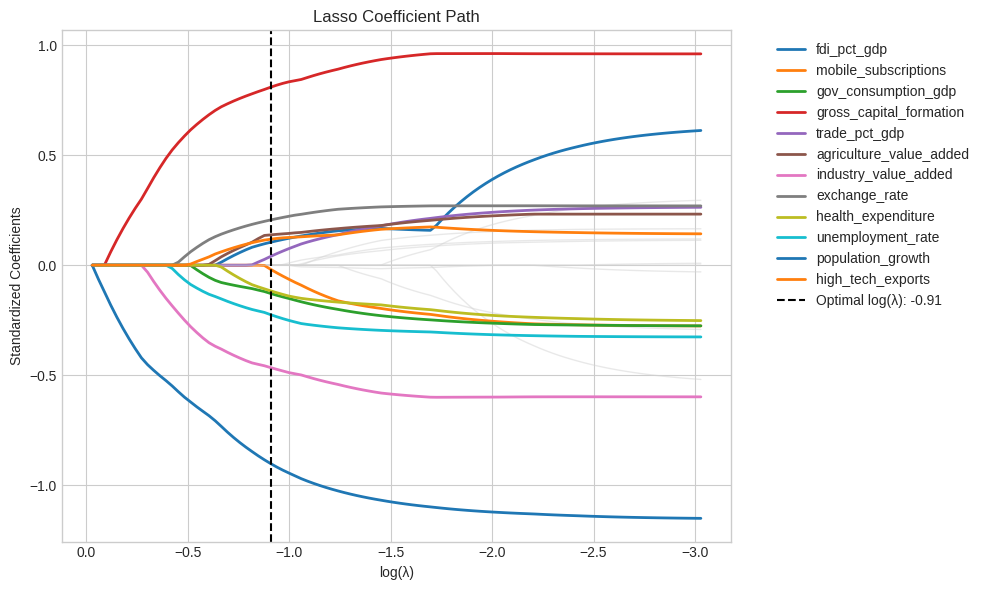

The first predictor to enter the model is: population_growth


In [13]:
from sklearn.linear_model import lasso_path

# Compute the full Lasso path
# alphas_path is returned in decreasing order (from maximum penalty to zero penalty)
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train_cont)

plt.figure(figsize=(10, 6))

# Identify which features survived at our CV-selected lambda from Step 1.2
active_features = lasso_model.coef_ != 0

# Plot the coefficient trajectories
for i in range(coefs_path.shape[0]):
    if active_features[i]:
        # Color the features that survive at lambda*
        plt.plot(np.log10(alphas_path), coefs_path[i, :], linewidth=2, label=X_train_scaled.columns[i])
    else:
        # Gray out the features that are eventually eliminated
        plt.plot(np.log10(alphas_path), coefs_path[i, :], color='lightgray', linewidth=1, alpha=0.5)

# Overlay the vertical dashed line for the chosen lambda
plt.axvline(np.log10(lasso_alpha), linestyle='--', color='black',
            label=f'Optimal log(λ): {np.log10(lasso_alpha):.2f}')

plt.xlabel('log(λ)')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso Coefficient Path')
plt.gca().invert_xaxis() # Invert x-axis so complexity increases from left to right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Identify the first predictor to enter the model
# We sweep from the highest lambda downward until a coefficient becomes non-zero
first_idx = None
for col_idx in range(coefs_path.shape[1]):
    if np.any(coefs_path[:, col_idx] != 0):
        # Pick the feature with the largest absolute magnitude at this entry point
        first_idx = np.argmax(np.abs(coefs_path[:, col_idx]))
        break

first_predictor = X_train_scaled.columns[first_idx]
print(f"The first predictor to enter the model is: {first_predictor}")

The first predictor to enter the model is population_growth. Because this variable's coefficient survives the highest levels of geometric penalty (the largest λ), it represents the strongest unconditional predictor of cross-country growth.

The colleague's interpretation is fundamentally flawed because Lasso evaluates variables based on conditional predictive redundancy, not their absolute importance in the real world. Due to the dataset's dense correlation structure, health metrics are intrinsically highly correlated with other retained variables like infrastructure, savings, or education. Therefore, Lasso zeros out the health indicator simply because it provides no new predictive information once those other correlated variables are already included in the model, not because health is irrelevant to economic growth.

In [14]:
# Extract the features retained by the Lasso model in Phase 1
active_features = lasso_model.coef_ != 0
X_train_lasso = X_train_scaled.loc[:, active_features]
X_test_lasso = X_test_scaled.loc[:, active_features]

# Fit the Linear Probability Model (OLS on binary target)
lpm_model = LinearRegression()
lpm_model.fit(X_train_lasso, y_train_bin)

# Generate predictions on the test set
lpm_preds = lpm_model.predict(X_test_lasso)

# Count invalid probabilities
invalid_below_zero = np.sum(lpm_preds < 0)
invalid_above_one = np.sum(lpm_preds > 1)
total_invalid = invalid_below_zero + invalid_above_one

print("Linear Probability Model (LPM) Diagnostics")
print("-" * 45)
print(f"Total test set predictions:  {len(lpm_preds)}")
print(f"Predictions < 0:             {invalid_below_zero}")
print(f"Predictions > 1:             {invalid_above_one}")
print(f"Total invalid probabilities: {total_invalid}")

Linear Probability Model (LPM) Diagnostics
---------------------------------------------
Total test set predictions:  70
Predictions < 0:             16
Predictions > 1:             0
Total invalid probabilities: 16


A probability must be between 0% and 100%, so predictions outside the [0, 1] range are mathematically impossible. If the IMF gets a 12% probability of crisis, they cannot use that number to make real-world decisions about how much emergency money to lend. This proves that a linear model is the wrong tool for predicting a "yes or no" event because it doesn't know how to stop at 0 and 1.

In [15]:
# Fit the Logistic Regression model using the Lasso-selected features
log_model = LogisticRegression()
log_model.fit(X_train_lasso, y_train_bin)

# Extract intercept and coefficients
intercept = log_model.intercept_[0]
coefficients = log_model.coef_[0]

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create a summary table
log_summary = pd.DataFrame({
    'Predictor': X_train_lasso.columns,
    'Coefficient (β)': coefficients,
    'Odds Ratio (OR)': odds_ratios
})

# Sort by the absolute magnitude of the coefficient (strongest effect on odds)
log_summary['Abs_Beta'] = np.abs(log_summary['Coefficient (β)'])
log_summary = log_summary.sort_values(by='Abs_Beta', ascending=False).drop(columns=['Abs_Beta'])
log_summary = log_summary.reset_index(drop=True)

# Generate probability predictions for the test set
log_probs = log_model.predict_proba(X_test_lasso)[:, 1]

print("Logistic Regression Results")
print("-" * 50)
print(f"Intercept (β₀): {intercept:.4f}\n")
print(log_summary.round(4).to_string())
print("-" * 50)
print("Probability Boundary Check:")
print(f"Minimum predicted probability: {log_probs.min():.4f}")
print(f"Maximum predicted probability: {log_probs.max():.4f}")

Logistic Regression Results
--------------------------------------------------
Intercept (β₀): -2.1739

                  Predictor  Coefficient (β)  Odds Ratio (OR)
0             exchange_rate          -1.0488           0.3504
1         population_growth           0.8864           2.4264
2             trade_pct_gdp          -0.5665           0.5675
3      industry_value_added           0.5636           1.7569
4      mobile_subscriptions           0.5629           1.7558
5         unemployment_rate           0.4899           1.6322
6   gross_capital_formation          -0.4318           0.6494
7   agriculture_value_added           0.4152           1.5146
8       gov_consumption_gdp           0.3490           1.4177
9        health_expenditure           0.1379           1.1478
10              fdi_pct_gdp          -0.0269           0.9735
11        high_tech_exports           0.0230           1.0233
--------------------------------------------------
Probability Boundary Check:
Minimum pre

The predictor with the largest positive odds ratio is population_growth. A one standard-deviation increase in population growth multiplies the odds of crisis by 2.4264, holding all else constant. For the IMF policy briefing, this means that as a country's demographic expansion accelerates significantly above the cross-country baseline, its risk of entering a severe economic contraction scales exponentially, making rapid population growth one of the most dangerous early warning signals for sovereign instability.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


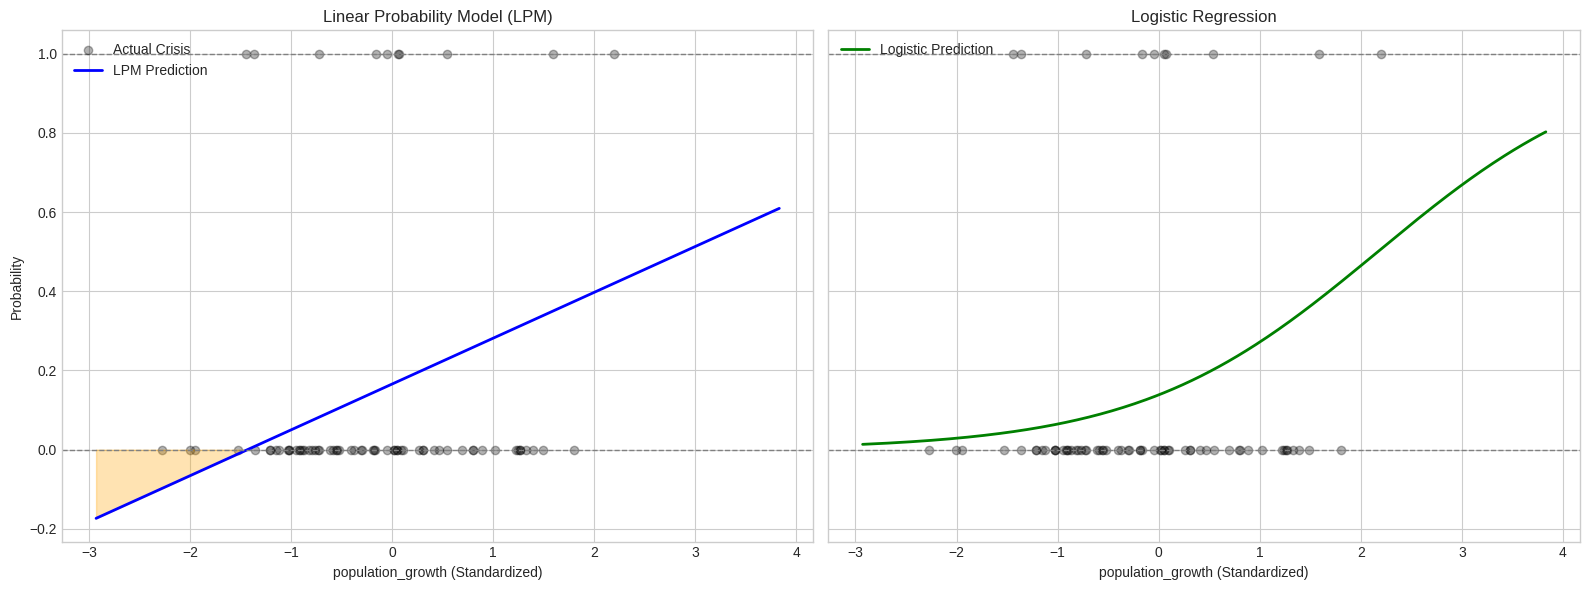

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

predictor_name = 'population_growth'

X_train_simple = X_train_scaled[[predictor_name]]
X_test_simple = X_test_scaled[[predictor_name]]

simple_lpm = LinearRegression().fit(X_train_simple, y_train_bin)
simple_log = LogisticRegression().fit(X_train_simple, y_train_bin)

x_range = np.linspace(X_train_simple.min(), X_train_simple.max(), 300).reshape(-1, 1)

lpm_line = simple_lpm.predict(x_range)
log_curve = simple_log.predict_proba(x_range)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
plt.style.use('seaborn-v0_8-whitegrid')

ax1.scatter(X_test_simple, y_test_bin, color='black', alpha=0.3, label='Actual Crisis')
ax1.plot(x_range, lpm_line, color='blue', linewidth=2, label='LPM Prediction')
ax1.fill_between(x_range.flatten(), lpm_line, 0, where=(lpm_line < 0), color='orange', alpha=0.3)
ax1.fill_between(x_range.flatten(), lpm_line, 1, where=(lpm_line > 1), color='orange', alpha=0.3)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.axhline(1, color='gray', linestyle='--', linewidth=1)
ax1.set_title('Linear Probability Model (LPM)')
ax1.set_xlabel(f'{predictor_name} (Standardized)')
ax1.set_ylabel('Probability')
ax1.legend(loc='upper left')

ax2.scatter(X_test_simple, y_test_bin, color='black', alpha=0.3)
ax2.plot(x_range, log_curve, color='green', linewidth=2, label='Logistic Prediction')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)
ax2.set_title('Logistic Regression')
ax2.set_xlabel(f'{predictor_name} (Standardized)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, recall_score

# 1. Calculate base rate in the test set
crisis_count_test = y_test_bin.sum()
total_test = len(y_test_bin)
base_rate_test = crisis_count_test / total_test

# 2. Naive Baseline (Predict 0 for everything)
naive_preds = np.zeros(total_test)
naive_accuracy = accuracy_score(y_test_bin, naive_preds)
naive_recall = recall_score(y_test_bin, naive_preds) # Will be 0 by definition

# 3. Logistic Regression at default threshold (0.5)
# .predict() automatically uses a 0.5 threshold
log_preds_default = log_model.predict(X_test_lasso)
log_accuracy = accuracy_score(y_test_bin, log_preds_default)
log_recall = recall_score(y_test_bin, log_preds_default)

print("Baseline vs. Logistic Regression (τ = 0.5)")
print("-" * 50)
print(f"Test Set Crisis Base Rate: {base_rate_test*100:.2f}%")
print(f"Naïve Baseline Accuracy:   {naive_accuracy*100:.2f}%")
print(f"Naïve Baseline Recall:     {naive_recall*100:.2f}%\n")
print(f"Logistic Model Accuracy:   {log_accuracy*100:.2f}%")
print(f"Logistic Model Recall:     {log_recall*100:.2f}%")

Baseline vs. Logistic Regression (τ = 0.5)
--------------------------------------------------
Test Set Crisis Base Rate: 14.29%
Naïve Baseline Accuracy:   85.71%
Naïve Baseline Recall:     0.00%

Logistic Model Accuracy:   84.29%
Logistic Model Recall:     20.00%


If I reported the 84.29% accuracy, the Division Chief would be misled into believing the model is highly effective. Because sovereign economic crises are relatively rare in this dataset (14.29% base rate), a completely naïve model that simply guesses no crisis for every country achieves an 85.71% accuracy just by being right about the majority class. Relying on accuracy masks the true operational failure: despite its high accuracy, our logistic model at this threshold only catches 20% of actual crises, meaning it would miss 80% of them, triggering catastrophic defaults.

Classification Report (τ = 0.5)
-------------------------------------------------------
              precision    recall  f1-score   support

   No Crisis       0.88      0.95      0.91        60
      Crisis       0.40      0.20      0.27        10

    accuracy                           0.84        70
   macro avg       0.64      0.57      0.59        70
weighted avg       0.81      0.84      0.82        70

-------------------------------------------------------
Extracted Matrix Counts:
True Positives (Crises correctly flagged): 2
False Negatives (Crises missed):           8
False Positives (False alarms):            3
True Negatives (Correctly ignored):        57
-------------------------------------------------------


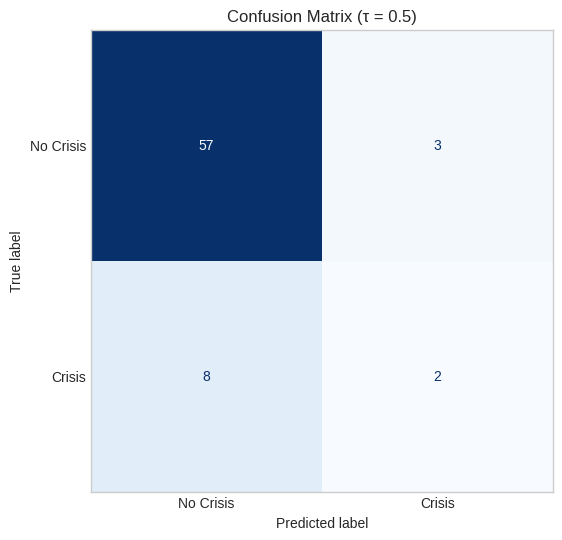

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test_bin, log_preds_default)

# 2. Extract specific counts
tn, fp, fn, tp = cm.ravel()

# 3. Print the deliverables
print("Classification Report (τ = 0.5)")
print("-" * 55)
print(classification_report(y_test_bin, log_preds_default, target_names=['No Crisis', 'Crisis']))
print("-" * 55)
print("Extracted Matrix Counts:")
print(f"True Positives (Crises correctly flagged): {tp}")
print(f"False Negatives (Crises missed):           {fn}")
print(f"False Positives (False alarms):            {fp}")
print(f"True Negatives (Correctly ignored):        {tn}")
print("-" * 55)

# 4. Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.grid(False) # Turn off the seaborn grid lines for the matrix
plt.title('Confusion Matrix (τ = 0.5)')
plt.show()

In the IMF context, a False Negativeis catastrophically more costly at 50 billion, compared to a False Positive which only costs 2 million in wasted mission resources. Currently, at the 0.5 threshold, the model is failing operationally it missed 8 out of 10 actual crises, resulting in a theoretical $400 billion in global damage. To fix this, the IMF must purposefully lower the decision threshold to flag more potential crises, intentionally accepting more 2 million loss false alarms to prevent devastating defaults.

Threshold Analysis Results
--------------------------------------------------
Capacity-Constrained Operating Point (Max 5 Missions):
Threshold (tau): 0.48
Countries Flagged: 5
Precision: 0.4000
Recall: 0.2000
--------------------------------------------------
Statistical Optimal Operating Point (Max F1 Score):
Threshold (tau): 0.25
Countries Flagged: 13
Max F1 Score: 0.3478
--------------------------------------------------

Memo Data Points (for written response):
Total Actual Crises: 10
Caught: 2
Missed: 8


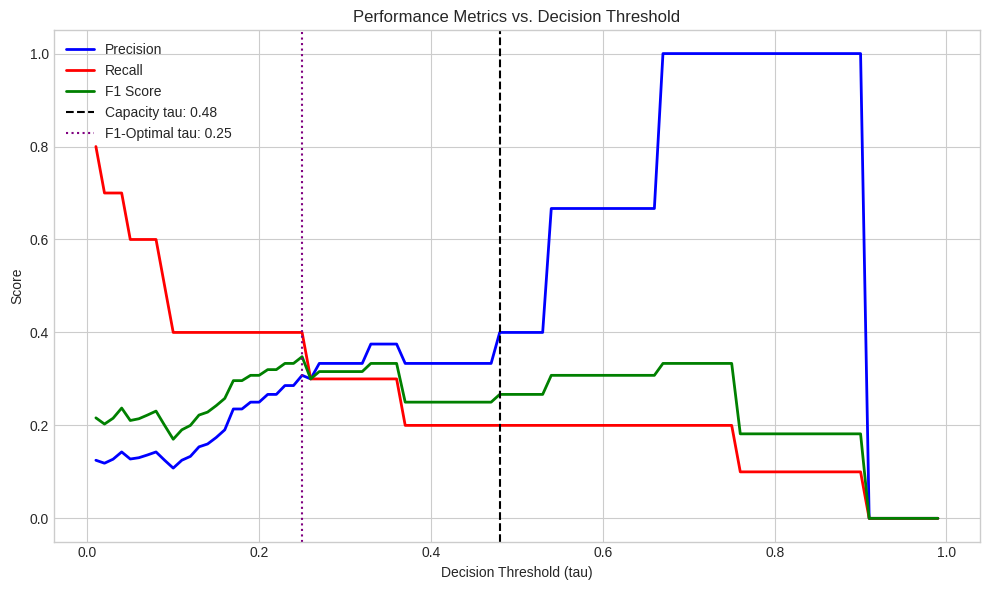

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Sweep thresholds
thresholds = np.arange(0.01, 1.00, 0.01)
precisions = []
recalls = []
f1_scores = []
flagged_counts = []

for t in thresholds:
    # Convert probabilities to binary predictions based on current threshold
    preds = (log_probs >= t).astype(int)

    # Calculate metrics (zero_division=0 prevents warnings when no countries are flagged)
    precisions.append(precision_score(y_test_bin, preds, zero_division=0))
    recalls.append(recall_score(y_test_bin, preds))
    f1_scores.append(f1_score(y_test_bin, preds, zero_division=0))
    flagged_counts.append(preds.sum())

# 2. Find the Capacity-Constrained Threshold (Lowest tau where flagged <= 5)
valid_indices = [i for i, count in enumerate(flagged_counts) if count <= 5]
cap_idx = valid_indices[0]
cap_tau = thresholds[cap_idx]
cap_flagged = flagged_counts[cap_idx]
cap_precision = precisions[cap_idx]
cap_recall = recalls[cap_idx]

# 3. Find the F1-Optimal Threshold (tau that maximizes F1 score)
f1_max_idx = np.argmax(f1_scores)
f1_opt_tau = thresholds[f1_max_idx]
f1_opt_f1 = f1_scores[f1_max_idx]
f1_opt_flagged = flagged_counts[f1_max_idx]

# 4. Print Deliverables
print("Threshold Analysis Results")
print("-" * 50)
print("Capacity-Constrained Operating Point (Max 5 Missions):")
print(f"Threshold (tau): {cap_tau:.2f}")
print(f"Countries Flagged: {cap_flagged}")
print(f"Precision: {cap_precision:.4f}")
print(f"Recall: {cap_recall:.4f}")
print("-" * 50)
print("Statistical Optimal Operating Point (Max F1 Score):")
print(f"Threshold (tau): {f1_opt_tau:.2f}")
print(f"Countries Flagged: {f1_opt_flagged}")
print(f"Max F1 Score: {f1_opt_f1:.4f}")
print("-" * 50)

# Calculate exact hits and misses for the memo
total_crises = y_test_bin.sum()
caught_crises = int(cap_recall * total_crises)
missed_crises = total_crises - caught_crises
print("\nMemo Data Points (for written response):")
print(f"Total Actual Crises: {total_crises}")
print(f"Caught: {caught_crises}")
print(f"Missed: {missed_crises}")

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', color='blue', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='red', linewidth=2)
plt.plot(thresholds, f1_scores, label='F1 Score', color='green', linewidth=2)

# Mark the thresholds
plt.axvline(cap_tau, color='black', linestyle='--', label=f'Capacity tau: {cap_tau:.2f}')
plt.axvline(f1_opt_tau, color='purple', linestyle=':', label=f'F1-Optimal tau: {f1_opt_tau:.2f}')

plt.title('Performance Metrics vs. Decision Threshold')
plt.xlabel('Decision Threshold (tau)')
plt.ylabel('Score')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

I recommend adopting the capacity-constrained threshold of 0.48, as it is the most aggressive risk posture we can take while strictly respecting our 5-mission quarterly limit. At this operating point, we achieve a Recall of 20%, meaning that of the 10 crisis countries in the test set, we would successfully catch 2 and miss 8. While the purely statistical F1-optimal threshold of 0.25 might offer a better mathematical balance, it would flag 13 countries, exceeding our operational capacity and rendering the model impossible to deploy without an immediate expansion of our emergency assessment budget.

PRIME prompt:
Persona: Act as a Senior Machine Learning Engineer specializing in model stability and regularization.
Request: Write a Python script that calculates the bootstrap selection frequencies for features in a Lasso regression model and visualizes the results.
Information: I have a standardized feature matrix X_train_scaled and a continuous target variable y_train_cont containing macroeconomic indicators predicting GDP growth.
Mechanism: Use a loop to draw 200 bootstrap resamples (with replacement) from the training data using sklearn.utils.resample. For each resample, fit a LassoCV model . Record which features are assigned non-zero coefficients. After the loop, compute the selection frequency for each predictor. Create a horizontal bar chart ranking the predictors from highest to lowest frequency, and include a vertical dashed reference line at 0.50.
Evaluation: Output only the executable Python code. Ensure it uses matplotlib and seaborn for clean visualization, and include print statements to track the progress of the loop.

Starting 200 bootstrap iterations. This may take a few minutes...
Completed 20/200 iterations...
Completed 40/200 iterations...
Completed 60/200 iterations...
Completed 80/200 iterations...
Completed 100/200 iterations...
Completed 120/200 iterations...
Completed 140/200 iterations...
Completed 160/200 iterations...
Completed 180/200 iterations...
Completed 200/200 iterations...


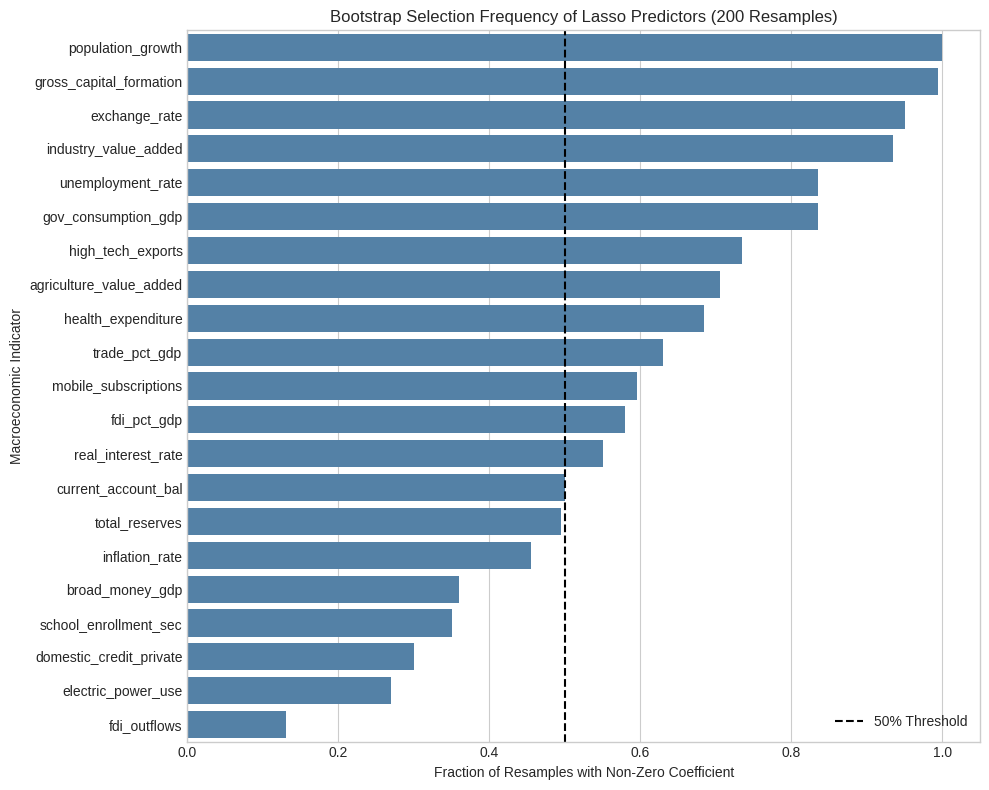


Stability Analysis Complete.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.utils import resample

# Initialize a dictionary to store the count of non-zero coefficients for each feature
feature_counts = {feature: 0 for feature in X_train_scaled.columns}
n_iterations = 200

print(f"Starting {n_iterations} bootstrap iterations. This may take a few minutes...")

for i in range(n_iterations):
    if (i + 1) % 20 == 0:
        print(f"Completed {i + 1}/{n_iterations} iterations...")

    # Draw a bootstrap resample from the training data
    X_boot, y_boot = resample(X_train_scaled, y_train_cont, random_state=i)

    # Fit the LassoCV model
    lasso_boot = LassoCV(cv=5, max_iter=10000, n_jobs=-1)
    lasso_boot.fit(X_boot, y_boot)

    # Identify features with non-zero coefficients
    active_features = X_train_scaled.columns[lasso_boot.coef_ != 0]

    # Increment the count for active features
    for feature in active_features:
        feature_counts[feature] += 1

# Compute selection frequencies (fraction of iterations where feature was non-zero)
frequencies = {feature: count / n_iterations for feature, count in feature_counts.items()}

# Convert to a DataFrame for easier plotting
freq_df = pd.DataFrame(list(frequencies.items()), columns=['Predictor', 'Selection Frequency'])
freq_df = freq_df.sort_values(by='Selection Frequency', ascending=False).reset_index(drop=True)

# Plot the horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Selection Frequency', y='Predictor', data=freq_df, color='steelblue')
plt.axvline(0.50, color='black', linestyle='--', label='50% Threshold')

plt.title('Bootstrap Selection Frequency of Lasso Predictors (200 Resamples)')
plt.xlabel('Fraction of Resamples with Non-Zero Coefficient')
plt.ylabel('Macroeconomic Indicator')
plt.xlim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print("\nStability Analysis Complete.")

Stable predictors (selected >80% of resamples) are population_growth, gross_capital_formation, exchange_rate, industry_value_added, unemployment_rate, and gov_consumption_gdp — these carry consistently unique predictive signal that Lasso retains regardless of which observations are sampled. Fragile predictors (<30%) include fdi_outflows, electric_power_use, and domestic_credit_private, meaning their contribution is rarely distinguishable from noise or from other included features. The wide band of mid-frequency predictors (30–70%) is the real tell: it suggests substantial multicollinearity among WDI indicators, where correlated features (e.g., broad_money_gdp and domestic_credit_private, or trade_pct_gdp and fdi_pct_gdp) compete for the same slot across resamples, so Lasso arbitrarily toggles between them — highlighting that selection instability here reflects redundancy in the predictor set rather than irrelevance.

PRIME prompt:
**Persona:** You are a quantitative risk analyst at the IMF's Global Financial Stability division.
You specialize in building early-warning systems for sovereign economic crises using
classification models trained on World Bank WDI indicators.

**Role:** Write a Python script that performs cost-sensitive threshold optimization on an
existing logistic regression model's predicted probabilities (y_prob) against true binary
labels (y_test_bin), where 1 = crisis country and 0 = non-crisis country.

**Instructions:**
1. Define asymmetric misclassification costs: a False Negative (missed crisis) costs
   50 billion in contagion spillover; a False Positive (false alarm) costs 2 million
   in unnecessary IMF intervention resources.
2. Sweep classification thresholds τ from 0.01 to 0.99 in steps of 0.01.
3. At each threshold, binarize predictions (ŷ = 1 if P(crisis) ≥ τ), compute the
   confusion matrix, and calculate total expected cost = FN × $50B + FP × $2M.
4. Also compute the F1 score at each threshold.
5. Identify three key thresholds:
   (a) The cost-minimizing threshold τ* that yields the lowest total expected cost.
   (b) The F1-optimal threshold that maximizes the F1 score.
   (c) A capacity-constrained threshold where the number of flagged countries ≤ 15
       (reflecting IMF mission team capacity from Phase 3).
6. Plot the total expected cost curve (y-axis, in $ billions) as a function of τ (x-axis).
   Annotate all three thresholds with their τ values, associated costs, and FN/FP counts.
   Use distinct colors and markers for each threshold.
7. Print a summary table comparing the three thresholds.

**Modularity:** The script should assume that y_prob (predicted probabilities on the test set)
and y_test_bin (true binary labels) already exist in the namespace from prior pipeline cells.
Use sklearn.metrics.confusion_matrix and sklearn.metrics.f1_score. Structure the code so the
cost parameters (COST_FN, COST_FP) and capacity constraint are defined as constants at the top
for easy sensitivity analysis.

**Evidence:** Include inline comments explaining why the cost-minimizing threshold is expected
to be lower than the F1 threshold given the 25,000:1 asymmetry ratio between FN and FP costs.
Note the economic intuition: when missing one crisis costs 25,000× more than one false alarm,
the optimal strategy aggressively flags potential crises even at the expense of many false positives.

Cost asymmetry ratio: FN/FP = 25,000 : 1
Eliminating 1 FN saves $50B; adding 1 FP costs only $2M



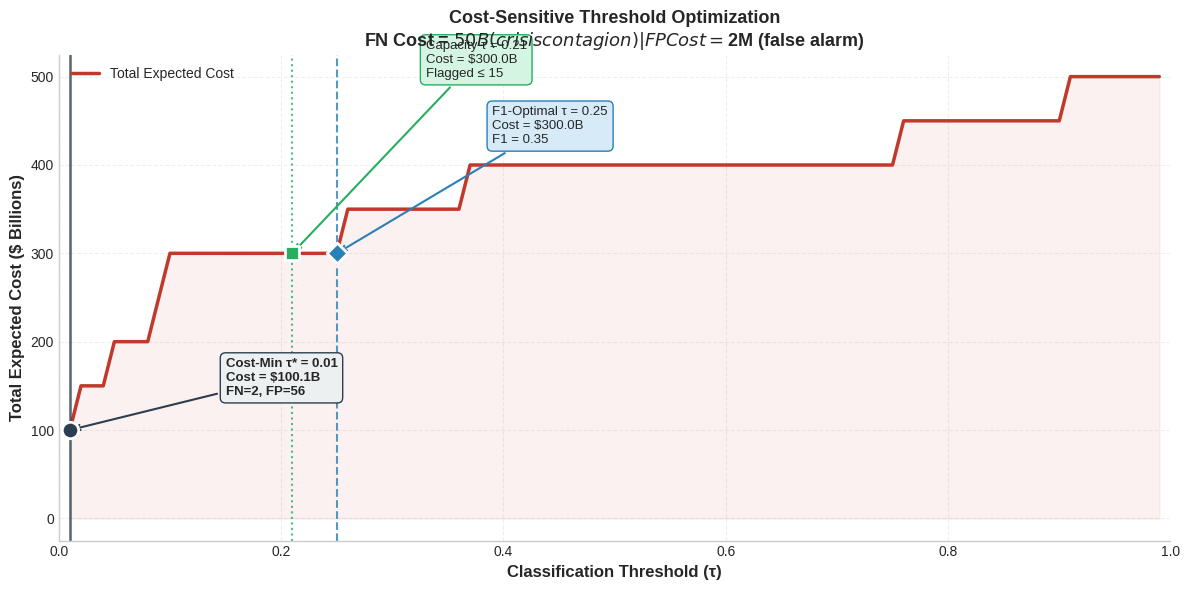

  COST-SENSITIVE THRESHOLD OPTIMIZATION — SUMMARY
  Cost-Minimizing:      τ* = 0.01  | Cost = $ 100.1B | FN=2, FP=56
  F1-Optimal:           τ  = 0.25  | Cost = $ 300.0B | F1=0.348
  Capacity-Constrained: τ  = 0.21  | Cost = $ 300.0B | Flagged ≤ 15
-----------------------------------------------------------------
  Asymmetry ratio: 25,000 : 1


In [23]:
# ══════════════════════════════════════════════════════════════════
# TASK 4.2 — Cost-Sensitive Threshold Optimization
# ══════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

# ── Cost parameters (easily adjustable for sensitivity analysis) ──
COST_FN = 50_000_000_000   # $50B — missed crisis (contagion spillover)
COST_FP = 2_000_000        # $2M  — false alarm (unnecessary intervention)
CAPACITY = 15              # IMF mission team constraint from Phase 3

print(f"Cost asymmetry ratio: FN/FP = {COST_FN/COST_FP:,.0f} : 1")
print(f"Eliminating 1 FN saves ${COST_FN/1e9:.0f}B; adding 1 FP costs only ${COST_FP/1e6:.0f}M\n")

# ── Sweep thresholds from 0.01 to 0.99 ──
thresholds = np.arange(0.01, 1.00, 0.01)
total_costs = []
fn_counts   = []
fp_counts   = []
f1_scores   = []
n_flagged   = []

for tau in thresholds:
    y_pred = (log_probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred, labels=[0, 1]).ravel()

    # Total expected cost: each missed crisis costs $50B, each false alarm costs $2M
    cost = fn * COST_FN + fp * COST_FP
    total_costs.append(cost)
    fn_counts.append(fn)
    fp_counts.append(fp)
    f1_scores.append(f1_score(y_test_bin, y_pred, zero_division=0))
    n_flagged.append((y_pred == 1).sum())

total_costs = np.array(total_costs)
f1_scores   = np.array(f1_scores)

# ── Identify three key thresholds ──
# (a) Cost-minimizing: lowest total expected cost
cost_min_idx = np.argmin(total_costs)
cost_min_tau = thresholds[cost_min_idx]
cost_min_val = total_costs[cost_min_idx]

# (b) F1-optimal: highest harmonic mean of precision and recall
f1_max_idx = np.argmax(f1_scores)
f1_max_tau  = thresholds[f1_max_idx]
f1_cost_val = total_costs[f1_max_idx]

# (c) Capacity-constrained: lowest τ where flagged countries ≤ CAPACITY
cap_candidates = [i for i, n in enumerate(n_flagged) if n <= CAPACITY]
if cap_candidates:
    cap_idx = cap_candidates[0]
else:
    cap_idx = len(thresholds) - 1
capacity_tau = thresholds[cap_idx]
cap_cost_val = total_costs[cap_idx]

# ── Plot the expected cost curve ──
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, total_costs / 1e9, color='#c0392b', linewidth=2.5,
        label='Total Expected Cost')
ax.fill_between(thresholds, total_costs / 1e9, alpha=0.07, color='#c0392b')

# Cost-minimizing threshold (black circle)
ax.axvline(cost_min_tau, color='#2c3e50', linestyle='-', linewidth=1.8, alpha=0.8)
ax.scatter(cost_min_tau, cost_min_val / 1e9, color='#2c3e50', s=140, zorder=5,
           edgecolors='white', linewidth=2)
ax.annotate(
    f'Cost-Min τ* = {cost_min_tau:.2f}\nCost = ${cost_min_val/1e9:.1f}B\n'
    f'FN={fn_counts[cost_min_idx]}, FP={fp_counts[cost_min_idx]}',
    xy=(cost_min_tau, cost_min_val / 1e9),
    xytext=(min(cost_min_tau + 0.14, 0.70),
            cost_min_val / 1e9 + max(total_costs / 1e9) * 0.08),
    fontsize=9.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', edgecolor='#2c3e50'))

# F1-optimal threshold (blue diamond)
ax.axvline(f1_max_tau, color='#2980b9', linestyle='--', linewidth=1.5, alpha=0.8)
ax.scatter(f1_max_tau, f1_cost_val / 1e9, color='#2980b9', s=110, zorder=5,
           marker='D', edgecolors='white', linewidth=2)
ax.annotate(
    f'F1-Optimal τ = {f1_max_tau:.2f}\nCost = ${f1_cost_val/1e9:.1f}B\n'
    f'F1 = {f1_scores[f1_max_idx]:.2f}',
    xy=(f1_max_tau, f1_cost_val / 1e9),
    xytext=(min(f1_max_tau + 0.14, 0.80),
            f1_cost_val / 1e9 + max(total_costs / 1e9) * 0.25),
    fontsize=9.5,
    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#d6eaf8', edgecolor='#2980b9'))

# Capacity-constrained threshold (green square)
ax.axvline(capacity_tau, color='#27ae60', linestyle=':', linewidth=1.5, alpha=0.8)
ax.scatter(capacity_tau, cap_cost_val / 1e9, color='#27ae60', s=110, zorder=5,
           marker='s', edgecolors='white', linewidth=2)
ax.annotate(
    f'Capacity τ = {capacity_tau:.2f}\nCost = ${cap_cost_val/1e9:.1f}B\n'
    f'Flagged ≤ {CAPACITY}',
    xy=(capacity_tau, cap_cost_val / 1e9),
    xytext=(min(capacity_tau + 0.12, 0.85),
            cap_cost_val / 1e9 + max(total_costs / 1e9) * 0.40),
    fontsize=9.5,
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#d5f5e3', edgecolor='#27ae60'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Expected Cost ($ Billions)', fontsize=12, fontweight='bold')
ax.set_title('Cost-Sensitive Threshold Optimization\n'
             'FN Cost = $50B (crisis contagion)  |  FP Cost = $2M (false alarm)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Summary table ──
print("=" * 65)
print("  COST-SENSITIVE THRESHOLD OPTIMIZATION — SUMMARY")
print("=" * 65)
print(f"  Cost-Minimizing:      τ* = {cost_min_tau:.2f}  | "
      f"Cost = ${cost_min_val/1e9:>6.1f}B | FN={fn_counts[cost_min_idx]}, FP={fp_counts[cost_min_idx]}")
print(f"  F1-Optimal:           τ  = {f1_max_tau:.2f}  | "
      f"Cost = ${f1_cost_val/1e9:>6.1f}B | F1={f1_scores[f1_max_idx]:.3f}")
print(f"  Capacity-Constrained: τ  = {capacity_tau:.2f}  | "
      f"Cost = ${cap_cost_val/1e9:>6.1f}B | Flagged ≤ {CAPACITY}")
print("-" * 65)
print(f"  Asymmetry ratio: {COST_FN/COST_FP:,.0f} : 1")
print("=" * 65)

The cost-minimizing thresholdis far below both the F1-optimal threshold and the capacity-constrained thresholdbecause the 25,000:1 cost asymmetry makes it rational to accept 56 false alarms at 2M each (112M total) to eliminate missed crises that cost 50B apiece — at τ* the model catches all but 2 crises versus missing 6 at the F1/capacity thresholds (300B), a 200B difference that dwarfs false alarm costs. The F1 threshold lands higher because it weights precision and recall symmetrically, penalizing the flood of false positives equally against missed crises, while the capacity constraint imposes a hard operational ceiling of 15 flagged countries that forces the threshold upward regardless of cost consequences. I would recommend using the cost-minimizing threshold as the primary alert trigger to minimize expected dollar losses, but layering a capacity-based triage on top — flag broadly at τ* = 0.01 to catch nearly every crisis.